# Exploration: Fire Stations
**STATIONS AND OPERATIONAL AREAS**

---

**Zweck:** Die Standorte der Berliner Feuerwehr und ihre Einsatzbereiche prüfen, mit den Ausrückzeiten und den LOR-Flächen verbinden und erste räumliche Merkmale (Abstand zur nächsten Wache) ableiten.  
**Input:** `seed_stations`, `app_data/geo/fire_operational_areas.geojson`, `lor_planning_room.geojson`, `stg_turnout_times`, `fct_timegoal_region_yearly`.  
**Output:** Fazit zu Inhalt, Nutzen und Grenzen; Kandidaten für `03_analysis_geo`.

## Setup

In [1]:
from berlin_emergency_response.notebook import *
import duckdb
from wgnd.viz import bar, line

setup_plotting()
con = duckdb.connect(str(PATHS["db"]), read_only=True)

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

✓  wgnd theme activated (matplotlib · seaborn)

## Structure

### Sites

Quelle: Berliner Feuerwehr, "Feuerwehr Standorte und Einsatzbereiche" (Geoportal Berlin, WFS `feuerwehr`, Lizenz dl-de-zero-2.0). `scripts/fetch_stations.py` lädt die Standorte als Seed `seed_stations` und die sechs Einsatzbereiche als GeoJSON. Typen: `BF` (Berufsfeuerwehr), `FF` (Freiwillige Feuerwehr), `RW` (Rettungswache).

In [2]:
df_st = q('select * from seed_stations order by station_id')
show_df(df_st.head(5))
inspect(df_st, sections=['dimensions', 'missing'])

,station_id,station_name,station_type,volunteer_id,address,postcode,district_name,operational_area,lon,lat,source_date
0,1100,FW-MITTE (LRW),BF,-,Voltairestraße 2,10179,Mitte,EB E 1,13.41,52.52,18.09.2024
1,1110,FF-MITTE,FF,-,Linienstraße 128 - 129,10115,Mitte,EB E 1,13.39,52.53,18.09.2024
2,1200,FW-FRIEDRICHSHAIN,BF,1201,Rüdersdorfer Straße 57,10243,Friedrichshain-Kreuzberg,EB E 1,13.44,52.51,18.09.2024
3,1204,RTW-FRIEDRICHSHAIN (KRH),RW,-,Landsberger Allee 49,10249,Friedrichshain-Kreuzberg,EB E 1,13.44,52.53,18.09.2024
4,1300,FW-PRENZLAUER BERG,BF,-,Oderberger Straße 24 - 25,10435,Pankow,EB E 2,13.41,52.54,18.09.2024



───  DIMENSIONS  ─────────────────────────────────────────────


,metric,count,pct
0,rows,102,
1,columns,11,
2,duplicates,0,0.0%
3,empty rows (all NaN),0,0.0%
4,empty cols (all NaN),0,0.0%



───  MISSING VALUES  ─────────────────────────────────────────
✓  No missing values.


In [3]:
df_type = q("""
    select district_name, count(*) filter (where station_type = 'BF') as bf, count(*) filter (where station_type = 'FF') as ff,
           count(*) filter (where station_type = 'RW') as rw, count(*) as stations
    from seed_stations group by 1 order by stations desc
""")
show_df(df_type)
show_df(q('select min(source_date) as source_date_min, max(source_date) as source_date_max, count(distinct source_date) as distinct_dates from seed_stations'))

,district_name,bf,ff,rw,stations
0,Treptow-Köpenick,2,10,5,17
1,Pankow,3,10,2,15
2,Marzahn-Hellersdorf,4,5,2,11
3,Charlottenburg-Wilmersdorf,6,0,3,9
4,Reinickendorf,6,3,0,9
5,Spandau,2,3,3,8
6,Mitte,3,1,3,7
7,Tempelhof-Schöneberg,3,1,3,7
8,Lichtenberg,2,3,1,6
9,Steglitz-Zehlendorf,4,0,2,6


,source_date_min,source_date_max,distinct_dates
0,18.09.2024,18.09.2024,1


### Coordinates

In [4]:
import numpy as np
import json
import shapely
from shapely import affinity
from shapely.geometry import Point, shape

def haversine_km(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, (lon1, lat1, lon2, lat2))
    a = np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2
    return 2 * 6371.0 * np.arcsin(np.sqrt(a))

lon, lat = df_st['lon'].to_numpy(), df_st['lat'].to_numpy()
d = haversine_km(lon[:, None], lat[:, None], lon[None, :], lat[None, :])
np.fill_diagonal(d, np.inf)
df_st['nearest_site_km'] = d.min(axis=1)
show_df(df_st.groupby('station_type')['nearest_site_km'].describe().round(2).reset_index())
show_df(df_st[df_st['nearest_site_km'] < 0.1][['station_id', 'station_name', 'station_type', 'nearest_site_km']])

,station_type,count,mean,std,min,25%,50%,75%,max
0,BF,40.00,1.67,1.03,0.04,1.16,1.58,2.19,3.89
1,FF,37.00,2.06,1.00,0.29,1.33,1.94,2.69,3.89
2,RW,25.00,1.36,0.61,0.29,0.98,1.36,1.59,2.52


,station_id,station_name,station_type,nearest_site_km
45,3600,FW-CHARLOTTENBURG NORD,BF,0.07
47,3639,TD 1,BF,0.07
48,3649,Fernmeldeeinsatzdienst,BF,0.07
81,6100,FW-MARZAHN,BF,0.04
85,6139,TD 2,BF,0.07
86,6149,Fernmeldeinsatzdienst (FW Marzahn),BF,0.04


Standorte, die weniger als 100 m auseinanderliegen, sind meist ein gemeinsames Gelände (zum Beispiel Berufs- und Freiwillige Feuerwehr an einer Adresse).

## Operational Areas

In [5]:
areas = json.loads((PATHS['app_data'] / 'geo' / 'fire_operational_areas.geojson').read_text(encoding='utf-8'))
rows = []
for f in areas['features']:
    g = shape(f['geometry'])
    rows.append({'operational_area': f['properties']['eb_kurz'], 'name': f['properties']['eb_name'],
                 'area_km2': round(affinity.scale(g, xfact=111.32 * np.cos(np.deg2rad(52.5)), yfact=110.57, origin=(0, 0)).area, 0), 'geom': g})
df_eb = pd.DataFrame(rows)
df_eb_count = df_st.groupby('operational_area')['station_type'].value_counts().unstack(fill_value=0).reset_index()
show_df(df_eb.drop(columns='geom').merge(df_eb_count, on='operational_area'))

,operational_area,name,area_km2,BF,FF,RW
0,EB E 1,Mitte / Friedrichshain-Kreuzberg,59.00,8,1,4
1,EB E 2,Pankow / Reinickendorf,191.00,7,13,2
2,EB E 3,Spandau / Charlottenburg-Wilmersdorf,155.00,8,3,6
3,EB E 4,Steglitz-Zehlendorf / Tempelhof-Schöneberg,154.00,7,1,5
4,EB E 5,Neukölln / Treptow-Köpenick,211.00,4,11,4
5,EB E 6,Lichtenberg / Marzahn-Hellersdorf,113.00,6,8,4


Liegt jeder Standort in dem Einsatzbereich, dem er zugeordnet ist?

In [6]:
def eb_of(lon, lat):
    p = Point(lon, lat)
    hits = [r['operational_area'] for _, r in df_eb.iterrows() if r['geom'].contains(p)]
    return hits[0] if hits else None

df_st['eb_by_point'] = [eb_of(a, b) for a, b in zip(df_st['lon'], df_st['lat'])]
bad = df_st[df_st['eb_by_point'] != df_st['operational_area']]
show_df(pd.DataFrame({'sites': [len(df_st)], 'inside_own_area': [int((df_st['eb_by_point'] == df_st['operational_area']).sum())],
                      'outside': [len(bad)]}))
show_df(bad[['station_id', 'station_name', 'operational_area', 'eb_by_point', 'district_name']])

,sites,inside_own_area,outside
0,102,102,0


,station_id,station_name,operational_area,eb_by_point,district_name


## Match with LOR

Wir ordnen jeden Standort per Punkt-in-Polygon einem Planungsraum zu und vergleichen den Bezirk (aus dem LOR-Präfix) mit dem Bezirk im Standort-Datensatz.

In [7]:
geo_pr = json.loads((PATHS['app_data'] / 'geo' / 'lor_planning_room.geojson').read_text(encoding='utf-8'))
pr = [(f['properties']['region_id'], shape(f['geometry'])) for f in geo_pr['features']]
tree = shapely.STRtree([g for _, g in pr])

def room_of(lon, lat):
    idx = tree.query(Point(lon, lat), predicate='within')
    return pr[idx[0]][0] if len(idx) else None

df_st['planning_room_id'] = [room_of(a, b) for a, b in zip(df_st['lon'], df_st['lat'])]
dist_names = q('select district_code, district_name as lor_district_name from dim_district')
df_st['district_code'] = df_st['planning_room_id'].str[:2]
df_m = df_st.merge(dist_names, on='district_code', how='left')
show_df(pd.DataFrame({'sites': [len(df_m)], 'assigned_to_planning_room': [int(df_m['planning_room_id'].notna().sum())],
                      'same_district': [int((df_m['district_name'] == df_m['lor_district_name']).sum())]}))
show_df(df_m[df_m['district_name'] != df_m['lor_district_name']][['station_id', 'station_name', 'district_name', 'lor_district_name', 'planning_room_id']])

,sites,assigned_to_planning_room,same_district
0,102,102,99


,station_id,station_name,district_name,lor_district_name,planning_room_id
11,2100,FW-SCHILLERPARK,Reinickendorf,Mitte,01400939
18,2500,FW-WEDDING,Reinickendorf,Mitte,01300836
100,6490,RTW-RUMMELSBURG (ASB),Treptow-Köpenick,Lichtenberg,11400928


## Coverage of the Turnout Data

In [8]:
df_t = q("""
    select t.station_id, any_value(t.station_name) as turnout_name, min(t.period) as first_period, max(t.period) as last_period,
           any_value(s.station_type) as station_type, any_value(s.station_name) as site_name
    from stg_turnout_times t left join seed_stations s using (station_id) group by t.station_id
""")
show_df(pd.DataFrame({'turnout_stations': [len(df_t)], 'with_site': [int(df_t['site_name'].notna().sum())], 'without_site': [int(df_t['site_name'].isna().sum())]}))
show_df(df_t[df_t['site_name'].isna()][['station_id', 'turnout_name', 'first_period', 'last_period']])
df_cov = q("""
    select s.station_type, count(*) as sites, count(*) filter (where s.station_id in (select station_id from stg_turnout_times)) as with_turnout
    from seed_stations s group by 1 order by 1
""")
show_df(df_cov)

,turnout_stations,with_site,without_site
0,80,77,3


,station_id,turnout_name,first_period,last_period
5,2402,Konradshöhe,2026_q1,current
57,6600,Hohenschönhausen,2026_q2,current
66,2202,Schönholz,2022_q4,2023_q3


,station_type,sites,with_turnout
0,BF,40,36
1,FF,37,18
2,RW,25,23


Turnout enthält laut BF nur Alarmierungen auf der Wache für dringliche Einsätze ohne Freiwillige Feuerwehr. Die Typen in der Tabelle stützen das.

### RTW Turnout by Type and District

Der Bezirk im Standort-Datensatz weicht bei drei Standorten von der Lage ab (siehe oben). Für Bezirksvergleiche nehmen wir deshalb den Bezirk aus dem LOR-Planungsraum, in dem der Punkt liegt.

In [9]:
df_tt = q("""
    select station_id, alarm_count_rtw, mean_turnout_seconds_rtw from stg_turnout_times
    where period_type = 'quarter' and period_start >= '2025-01-01' and period_end < current_date and alarm_count_rtw > 0
""").merge(df_m[['station_id', 'station_type', 'lor_district_name']], on='station_id')
df_tt['weighted'] = df_tt['alarm_count_rtw'] * df_tt['mean_turnout_seconds_rtw']
def summarize(df, key):
    g = df.groupby(key).agg(rtw_alarms=('alarm_count_rtw', 'sum'), w=('weighted', 'sum'), stations=('station_id', 'nunique')).reset_index()
    g['rtw_turnout_s'] = (g['w'] / g['rtw_alarms']).round(1)
    return g.drop(columns='w')
show_df(summarize(df_tt, 'station_type'))
show_df(summarize(df_tt, 'lor_district_name').sort_values('rtw_turnout_s'))

,station_type,rtw_alarms,stations,rtw_turnout_s
0,BF,291535,36,78.10
1,FF,45605,18,98.40
2,RW,52660,21,84.60


,lor_district_name,rtw_alarms,stations,rtw_turnout_s
1,Friedrichshain-Kreuzberg,38033,4,72.90
8,Spandau,28383,7,73.00
4,Mitte,45988,9,73.10
10,Tempelhof-Schöneberg,36313,7,74.90
7,Reinickendorf,25573,6,77.40
5,Neukölln,25455,3,77.60
0,Charlottenburg-Wilmersdorf,30987,6,81.50
11,Treptow-Köpenick,30387,8,82.40
9,Steglitz-Zehlendorf,28396,5,83.70
6,Pankow,39949,9,91.00


Auffällig: Auch Standorte vom Typ `FF` haben RTW-Alarmierungen in den Turnout-Daten. Die Annahme "die Freiwillige Feuerwehr stellt keinen RTW" trägt also nicht; wir leiten die RTW-Standorte deshalb aus den Daten ab (Wachen mit RTW-Alarmierungen seit 2025).

## Distance to the Nearest Station

Für jeden Planungsraum rechnen wir die Luftlinie vom Flächenschwerpunkt zum nächsten Standort. Drei Varianten: (a) Standorte mit RTW-Alarmierungen seit 2025 laut Turnout-Daten (aus den Daten abgeleitet), (b) `BF` und `RW`, (c) alle Typen. Danach der Zusammenhang mit der offiziellen Quote und dem Median der Antwortzeit (Planungsräume mit mindestens 30 auswertbaren Einsätzen). Rangkorrelation, Zusammenhänge statt Ursachen.

In [10]:
cent = pd.DataFrame([{'region_id': rid, 'lon': g.centroid.x, 'lat': g.centroid.y} for rid, g in pr])
def nearest_km(sites: pd.DataFrame) -> np.ndarray:
    return haversine_km(cent['lon'].to_numpy()[:, None], cent['lat'].to_numpy()[:, None], sites['lon'].to_numpy()[None, :], sites['lat'].to_numpy()[None, :]).min(axis=1)

rtw_ids = set(q("select distinct station_id from stg_turnout_times where period_type = 'quarter' and period_start >= '2025-01-01' and alarm_count_rtw > 0")['station_id'])
cent['nearest_rtw_km'] = nearest_km(df_st[df_st['station_id'].isin(rtw_ids)])
cent['nearest_rescue_km'] = nearest_km(df_st[df_st['station_type'].isin(['BF', 'RW'])])
cent['nearest_any_km'] = nearest_km(df_st)
cent['dist_centre_km'] = haversine_km(cent['lon'], cent['lat'], 13.4132, 52.5219)
df_f = q("""
    select data_year as year, region_id, ems_critical_timegoal_quote as ems_quote, response_time_ems_critical_median as ems_median_s,
           ems_critical_timegoal_computed as ems_n, fire_timegoal_quote as fire_quote, response_time_fire_time_to_first_pump_median as fire_pump_s,
           fire_timegoal_computed as fire_n, response_time_technical_rescue_median as tech_s, mission_count_all
    from fct_timegoal_region_yearly where region_level = 'planning_room'
""").merge(cent, on='region_id')
rank = lambda s: s.rank()
targets = {'ems_quote': ('ems_quote', 'ems_n', 30), 'ems_median_s': ('ems_median_s', 'ems_n', 30), 'fire_quote': ('fire_quote', 'fire_n', 10),
           'fire_pump_s': ('fire_pump_s', 'fire_n', 10), 'tech_s (no goal)': ('tech_s', 'mission_count_all', 30)}
rows = []
for year, g in df_f.groupby('year'):
    for feat in ['nearest_rtw_km', 'nearest_rescue_km', 'nearest_any_km', 'dist_centre_km']:
        row = {'year': year, 'feature': feat}
        for name, (col, n_col, n_min) in targets.items():
            h = g[g[n_col] >= n_min].dropna(subset=[col])
            row[name] = round(rank(h[feat]).corr(rank(h[col])), 2)
        rows.append(row)
show_df(pd.DataFrame(rows))
show_df(cent[['nearest_rtw_km', 'nearest_rescue_km', 'nearest_any_km', 'dist_centre_km']].describe().round(2).reset_index())

,year,feature,ems_quote,ems_median_s,fire_quote,fire_pump_s,tech_s (no goal)
0,2024,nearest_rtw_km,-0.66,0.65,-0.13,0.42,0.35
1,2024,nearest_rescue_km,-0.72,0.73,-0.22,0.51,0.40
2,2024,nearest_any_km,-0.57,0.57,-0.14,0.40,0.33
3,2024,dist_centre_km,-0.46,0.46,-0.44,0.47,0.29
4,2025,nearest_rtw_km,-0.61,0.65,-0.24,0.55,0.33
5,2025,nearest_rescue_km,-0.70,0.73,-0.30,0.62,0.42
6,2025,nearest_any_km,-0.54,0.57,-0.20,0.51,0.33
7,2025,dist_centre_km,-0.49,0.46,-0.50,0.56,0.30
8,2026,nearest_rtw_km,-0.60,0.66,-0.17,0.52,0.31
9,2026,nearest_rescue_km,-0.66,0.71,-0.20,0.55,0.38


,index,nearest_rtw_km,nearest_rescue_km,nearest_any_km,dist_centre_km
0,count,542.00,542.00,542.00,542.00
1,mean,1.27,1.52,1.17,8.94
2,std,0.72,1.00,0.61,4.55
3,min,0.10,0.10,0.10,0.22
4,25%,0.76,0.83,0.72,5.27
5,50%,1.14,1.28,1.07,8.52
6,75%,1.66,1.92,1.52,12.14
7,max,6.94,6.94,3.13,23.46


Je Einsatzart: Rettungsdienst (Quote, Median), Brandbekämpfung (Quote, Zeit bis zum ersten Löschfahrzeug) und technische Hilfe (nur Zeit, keine Frist). Für die Brandbekämpfung wäre der Abstand zu Wachen mit Löschfahrzeug passender; die Standortliste unterscheidet nur BF, FF und RW.

,station_band,regions,median_quote,median_response_s
0,"(0.0, 1.0]",223,0.68,549.00
1,"(1.0, 1.5]",147,0.63,583.00
2,"(1.5, 2.0]",96,0.52,626.50
3,"(2.0, 3.0]",60,0.43,662.50
4,"(3.0, 10.0]",12,0.25,726.00


Text(0.0, 1.0, 'Quote vs distance to nearest station, planning rooms 2025')

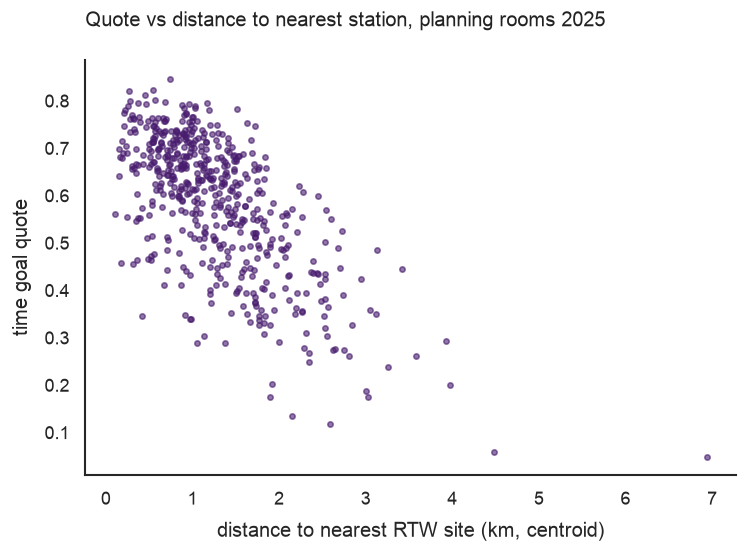

In [11]:
g = df_f[(df_f['year'] == 2025) & (df_f['ems_n'] >= 30)].rename(columns={'ems_quote': 'quote', 'ems_median_s': 'median_s'})
bands = g.assign(station_band=pd.cut(g['nearest_rtw_km'], [0, 1, 1.5, 2, 3, 10]))
df_band = bands.groupby('station_band', observed=True).agg(regions=('region_id', 'count'), median_quote=('quote', 'median'), median_response_s=('median_s', 'median')).round(2).reset_index()
show_df(df_band)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(g['nearest_rtw_km'], g['quote'], s=10, alpha=0.6)
ax.set_xlabel('distance to nearest RTW site (km, centroid)'); ax.set_ylabel('time goal quote'); ax.set_title('Quote vs distance to nearest station, planning rooms 2025')

Wie viel Eigenes bringt der Stationsabstand gegenüber dem Abstand zum Zentrum? Beide sind korreliert; Rangkorrelation untereinander:

In [12]:
show_df(pd.DataFrame({'pair': ['nearest_rtw_km vs dist_centre_km', 'nearest_rescue_km vs dist_centre_km', 'nearest_any_km vs dist_centre_km'],
    'rank_corr': [round(rank(cent['nearest_rtw_km']).corr(rank(cent['dist_centre_km'])), 2), round(rank(cent['nearest_rescue_km']).corr(rank(cent['dist_centre_km'])), 2), round(rank(cent['nearest_any_km']).corr(rank(cent['dist_centre_km'])), 2)]}))

,pair,rank_corr
0,nearest_rtw_km vs dist_centre_km,0.30
1,nearest_rescue_km vs dist_centre_km,0.40
2,nearest_any_km vs dist_centre_km,0.25


## Findings

### Content

102 Standorte der Berliner Feuerwehr (40 Berufsfeuerwehr, 37 Freiwillige Feuerwehr, 25 Rettungswachen) mit Wachennummer, Name, Adresse, Bezirk, Koordinaten und zugeordnetem Einsatzbereich, dazu die sechs Einsatzbereiche als Flächen (je zwei Bezirke). Alle Standorte haben denselben Stand (18.09.2024), der Datensatz wurde zuletzt 2024 aktualisiert. Lizenz dl-de-zero-2.0.

### Usefulness

* **Koordinaten der Wachen.** Damit rechnen wir den Abstand zur nächsten Wache für jeden Planungsraum, also die Standortdichte, die in der Fragestellung steht.
* **Verbindung zu den Ausrückzeiten:** Die Wachennummer ist dieselbe wie in `Turnout_Times`. 77 von 80 Wachen dort finden ihren Standort; damit lassen sich Ausrückzeiten nach Bezirk, Typ und Einsatzbereich auswerten.
* **Einsatzbereiche** als organisatorische Gliederung neben den Bezirken (Kontrollgruppe für Raumeffekte).

### Limits

* **Stand 2024.** Zwei Wachen, die in den Turnout-Daten ab 2026 auftauchen (Konradshöhe, Hohenschönhausen), fehlen hier, eine 2023 aufgegebene (Schönholz) ebenfalls. Der Abstand zur nächsten Wache gilt für den Stand 2024.
* **Keine Fahrzeuge, keine Besetzung.** Wir wissen nicht, wie viele RTW eine Wache stellt; ein Standort mit einem RTW zählt gleich wie einer mit mehreren.
* **Die Liste enthält nicht nur Wachen:** Einträge wie "TD 1", "TD 2" oder Fernmeldeeinsatzdienst sind Dienststellen auf dem Gelände einer Wache und als `BF` geführt. Für den Abstand ändert das praktisch nichts, für Zählungen schon.
* **Der Bezirk im Datensatz weicht bei drei Standorten von der Lage ab** (Schillerpark und Wedding: Reinickendorf statt Mitte, RTW-Rummelsburg: Treptow-Köpenick statt Lichtenberg). Für Raumauswertungen gilt der LOR-Bezirk des Punktes.
* **Der Typ sagt nicht, wer RTW stellt.** Auch `FF`-Standorte haben RTW-Alarmierungen. Welche Standorte als "Rettungswache" zählen, leiten wir aus den Ausrückdaten ab.
* **Abstand ist Luftlinie zum Flächenschwerpunkt der Region**, nicht Fahrweg zum Einsatzort. Zusammenhänge gelten auf Regionsebene.

### Observations

Stand der Ausführung. Zusammenhänge, keine Ursachen.

| Beobachtung | Beleg im Notebook |
|---|---|
| Keine fehlenden Werte, eindeutige Wachennummern; alle 102 Standorte liegen in ihrem Einsatzbereich und in einem Planungsraum | Sites, Operational Areas, Match with LOR |
| Bezirke mit wenigen Standorten (Neukölln, Friedrichshain-Kreuzberg) und solche mit vielen Freiwilligen Wachen (Treptow-Köpenick, Pankow) | Sites |
| Die mittlere RTW-Ausrückzeit je Standorttyp: Berufsfeuerwehr rund 78 s, Rettungswachen rund 85 s, Freiwillige rund 98 s | RTW Turnout by Type and District |
| Nach Bezirk (LOR) reicht sie von rund 73 s (Friedrichshain-Kreuzberg, Spandau, Mitte) bis rund 96 s (Lichtenberg, Marzahn-Hellersdorf) | RTW Turnout by Type and District |
| **Rettungsdienst: Je näher die nächste Wache, desto höher die Quote und desto kürzer die Antwortzeit:** Rangkorrelation mit der offiziellen Quote zwischen −0,5 und −0,7 je nach Wachen-Menge, in allen drei Jahren. Mit eingeengter Menge (RTW- bzw. Rettungsstandorte) stärker als der Abstand zum Zentrum (rund −0,5), mit allen Standorten ähnlich | Distance to the Nearest Station |
| Abstandsbänder (RTW-Standorte, 2025): Quote im Median von rund 68 % (bis 1 km) auf rund 43 % (2 bis 3 km), Antwortzeit von rund 549 s auf rund 663 s; über 3 km nur wenige Regionen | Distance to the Nearest Station |
| Stationsabstand und Zentrumsabstand sind nur mäßig verwandt (Rangkorrelation 0,25 bis 0,40): Der Stationsabstand trägt eigene Information | Distance to the Nearest Station |
| **Brandbekämpfung: Der Abstand zu Rettungsstandorten erklärt die Brand-Quote kaum** (Rangkorrelation rund −0,1 bis −0,3), der Abstand zum Zentrum dagegen deutlich (rund −0,45 bis −0,5). Für Löschfahrzeuge zählen andere Standorte als für Rettungswagen; eine Gesamtbetrachtung ohne Aufschlüsselung nach Einsatzart würde das verwischen | Distance to the Nearest Station |

### Open Questions

* **`02_preparation`:** `seed_stations` bleibt wie gefetcht; Auswertungsmart `dim_station` mit LOR-Bezirk und Planungsraum (Punkt in Polygon) und Kennzeichen `has_rtw_turnout`; Ausrückzeiten werden mit `seed_stations` verbunden. Die nicht auffindbaren Wachen als bekannte Lücke dokumentieren (`relationships`-Test steht auf `warn`).
* **`03_analysis_geo`:** Abstand zur nächsten Wache, Einsatzdichte und Bezirk gemeinsam betrachten (partielle Rangkorrelation oder einfache Regression auf Planungsräumen); Sensitivität gegenüber der Wachen-Menge prüfen (RTW-Standorte, BF plus RW, alle).
* **`03_analysis_geo`:** Antwortzeit je Bezirk gegen Einsatzbereich vergleichen: Wirkt die Organisation (Einsatzbereich) oder die Lage?
* **Aktualisierung:** Stand 2024; Nachfrage bei BF, ob eine neuere Fassung vorliegt, oder Koordinaten der zwei neuen Wachen separat belegen.